In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
telco_base_data =  pd.read_csv('Telco-Customer-Churn 2.csv')
telco_base_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
telco_base_data.shape

(7043, 21)

In [6]:
telco_base_data.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

In [7]:
telco_base_data.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [8]:
telco_base_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


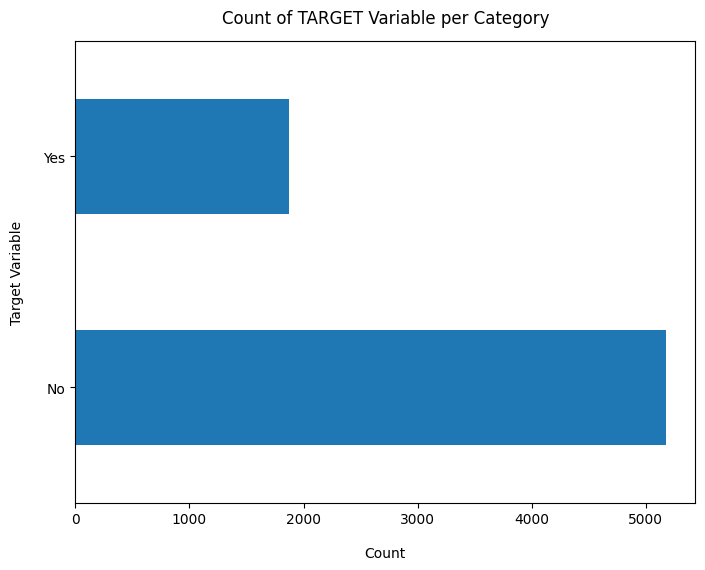

In [9]:
telco_base_data['Churn'].value_counts().plot(kind = 'barh', figsize = (8, 6))
plt.xlabel('Count', labelpad= 14)
plt.ylabel('Target Variable', labelpad= 14)
plt.title("Count of TARGET Variable per Category", y =1.02);

In [10]:
100*telco_base_data['Churn'].value_counts()/len(telco_base_data['Churn'])

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

In [11]:
telco_base_data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
telco_base_data.info(verbose = True)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

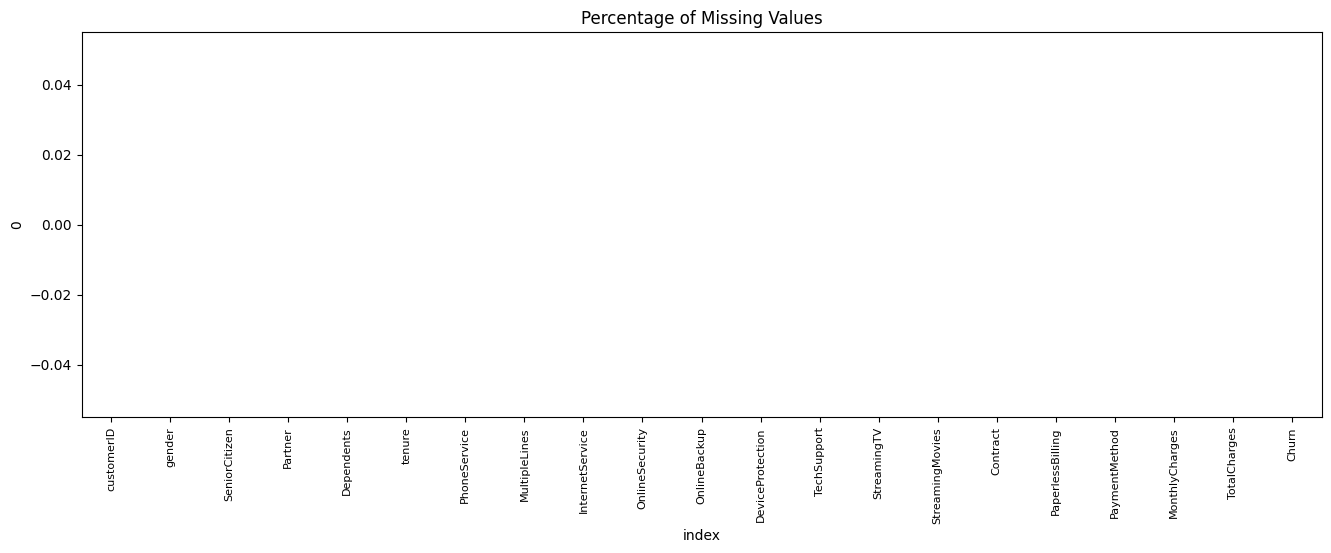

In [13]:
# Create a Dataframe with a percentage of missing value
missing = pd.DataFrame((telco_base_data.isnull().sum())/telco_base_data.shape[0]*100).reset_index()

# Set up the plot
plt.figure(figsize= (16, 5))

# Use a bar plot to visualize the percentage of missing values
ax = sns.barplot(x= 'index', y = 0, data = missing)
# Customize the plot
plt.xticks(rotation = 90, fontsize = 8)
plt.title('Percentage of Missing Values')

plt.show()

In [14]:
telco_data = telco_base_data.copy() # creating a copy allows us to experiment with the data without affecting the original dataset

In [15]:
telco_data.TotalCharges = pd.to_numeric(telco_data.TotalCharges, errors = 'coerce')
telco_data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

pd.to_numeric(telco_data.TotalCharges, errors='coerce')

Tries to convert the "TotalCharges" column into numeric values (integers or floats).

If a value can’t be converted (e.g., it’s blank or non-numeric text), errors='coerce' forces it to become NaN (missing value).

This is useful because "TotalCharges" often comes in as text, and you need it as numbers for analysis.

telco_data.TotalCharges = ...

Replaces the original "TotalCharges" column with the cleaned numeric version.

Line 2: Check Missing Values
telco_data.isnull()

Creates a DataFrame of True/False values showing where data is missing (NaN).

.sum()

Sums up the True values column by column.

The result is a count of missing values for each column in the dataset.

In Plain Terms
This code converts the "TotalCharges" column into numbers, replaces any invalid entries with missing values, and then shows you how many missing values exist in each column.

👉 It’s a cleaning step: making sure "TotalCharges" is numeric and checking the overall health of your dataset.

In [16]:
telco_data.loc[telco_data["TotalCharges"].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


telco_data["TotalCharges"]

Refers to the column "TotalCharges" in your DataFrame.

.isnull()

Checks each value in that column to see if it is missing (NaN).

Returns True for missing values, False otherwise.

== True

Explicitly filters only the rows where the condition is True (i.e., where "TotalCharges" is missing).

Note: you could simply write .isnull() without == True — it works the same way.

telco_data.loc[...]

Uses .loc to select rows that meet the condition.

So this returns all rows in telco_data where "TotalCharges" is missing.

In Plain Terms
This code finds and displays all customers whose TotalCharges value is missing in the dataset.

👉 It’s a diagnostic step — instead of dropping missing rows immediately, you’re checking which rows have the problem.

In [17]:
# Removing missing value
telco_data.dropna(how = 'any', inplace = True)

dropna()

A pandas function used to remove rows (or columns) that contain missing values (NaN).

how='any'

Means: if any column in a row has a missing value, drop that entire row.

(If you used how='all', it would only drop rows where all values are missing.)

inplace=True

Applies the change directly to the DataFrame telco_data.

Without this, pandas would return a new DataFrame and leave the original unchanged.

In Plain Terms
This code cleans your dataset by removing all rows that have at least one missing value, and it updates telco_data directly

In [18]:
#Get the max tenure
print(telco_data['tenure'].max()) #72 months

72


In [19]:
#Group the tenure in bins of 12 months
labels = ['{0} - {1}'.format(i, i + 11) for i in range(1, 72, 12)]

telco_data['tenure_group'] = pd.cut(telco_data.tenure, range(1, 80, 12), right = False, labels = labels)

In [20]:
telco_data['tenure_group'].value_counts()

tenure_group
1 - 12     2175
61 - 72    1407
13 - 24    1024
25 - 36     832
49 - 60     832
37 - 48     762
Name: count, dtype: int64

**labels = ['{0} - {1}'.format(i, i + 11) for i in range(1, 72, 12)]:**
This creates a list of text labels for groups of 12 months. The loop goes from 1 to 72 in steps of 12 → values: 1, 13, 25, 37, 49, 61.
For each value i, it makes a string like "1 - 12", "13 - 24", "25 - 36", etc.

**pd.cut(telco_data.tenure, range(1, 80, 12), right=False, labels=labels):**
pd.cut divides the tenure column (number of months a customer has stayed) into bins. range(1, 80, 12) creates intervals: [1,13), [13,25), [25,37), [37,49), [49,61), [61,73). right=False means the intervals are left-inclusive (e.g., 1–12 includes 1 but not 13). labels=labels assigns the text labels you created earlier to each bin.

**telco_data['tenure_group'] = ...:**
Adds a new column called "tenure_group" to the DataFrame. Each customer’s tenure is categorized into one of the labeled.

**telco_data['tenure_group']:**
Refers to the column "tenure_group" in your DataFrame. This column was created earlier when you grouped customers’ tenure into ranges like "1 - 12", "13 - 24", etc.

**.value_counts():**
Counts how many times each unique value appears in that column. In other words, it tells you how many customers fall into each tenure group.

In [21]:
# Drop column customerID and tenure
telco_data.drop(columns = ['customerID', 'tenure'], inplace = True)
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


**telco_data.drop()** → Removes specified rows or columns from the DataFrame.

**columns=['customerID', 'tenure']** → Specifies which columns to drop.
customerID: Often just an identifier, not useful for analysis.
tenure: Already transformed into tenure_group earlier, so the raw column may no longer be needed.

**axis=1 →** Indicates we are dropping columns (not rows).

**inplace=True** → Applies the change directly to telco_data without creating a new DataFrame.

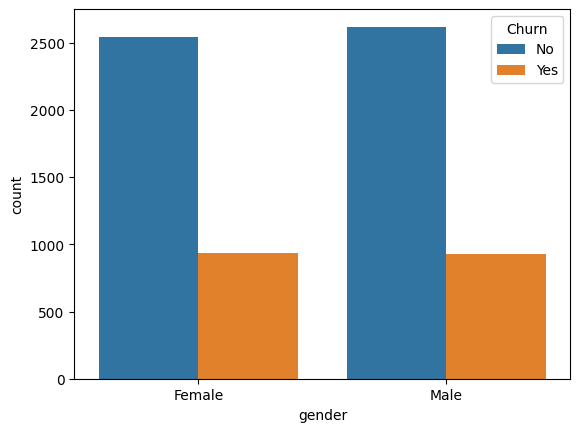

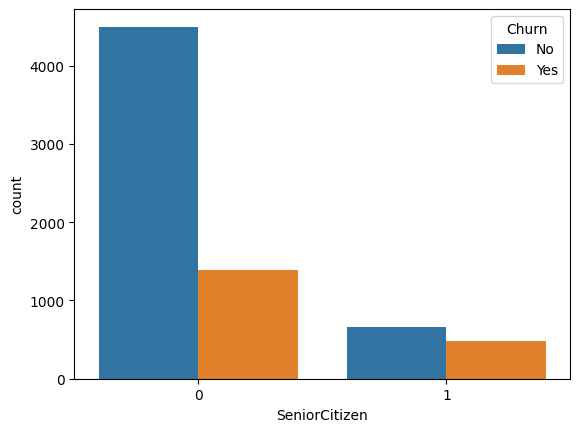

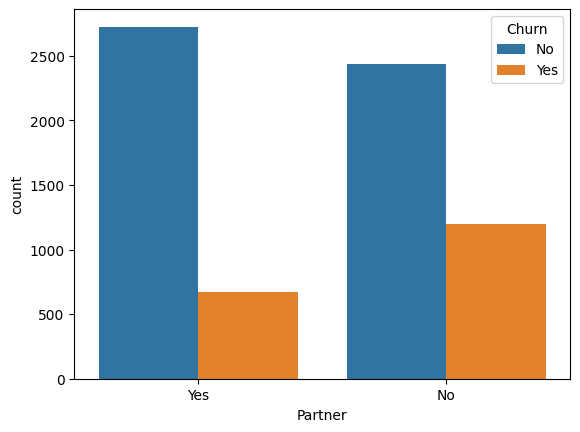

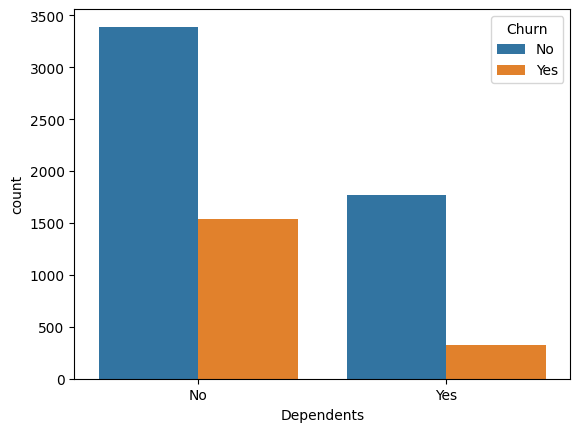

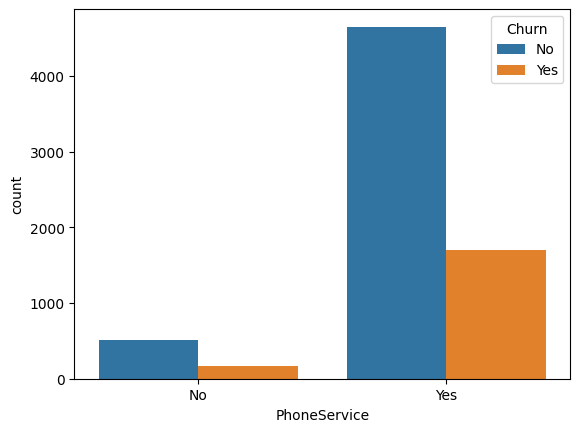

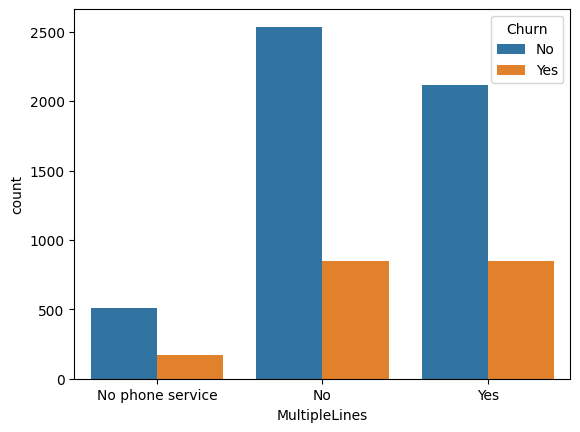

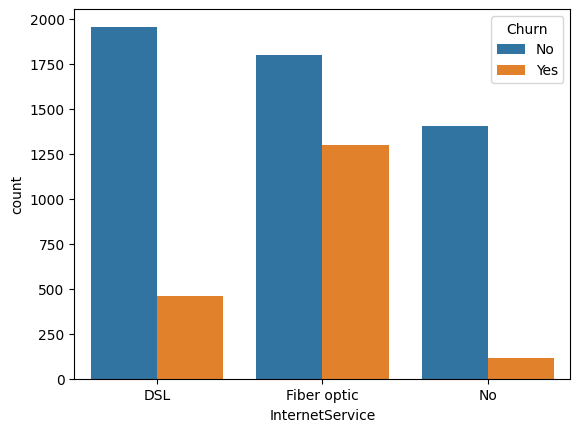

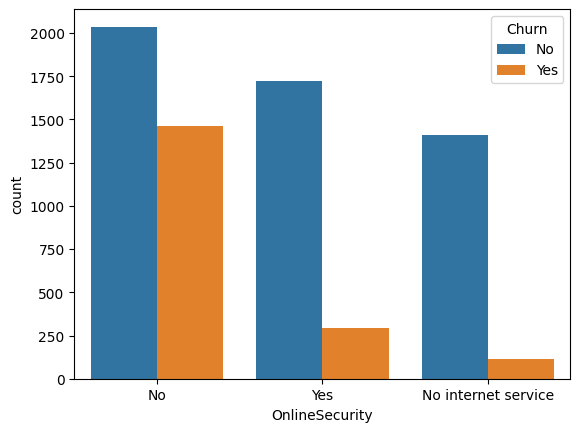

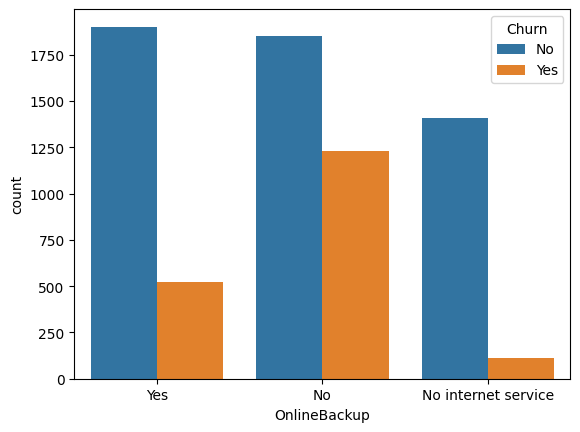

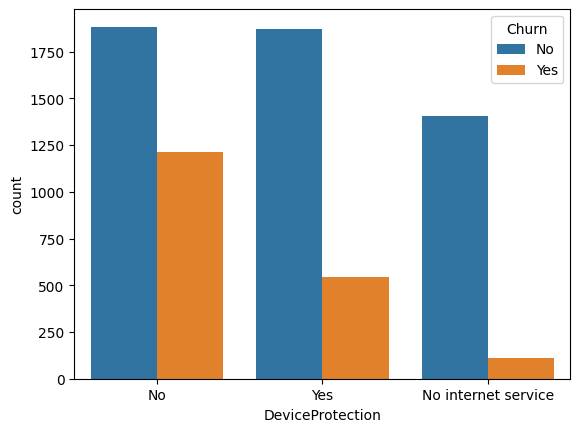

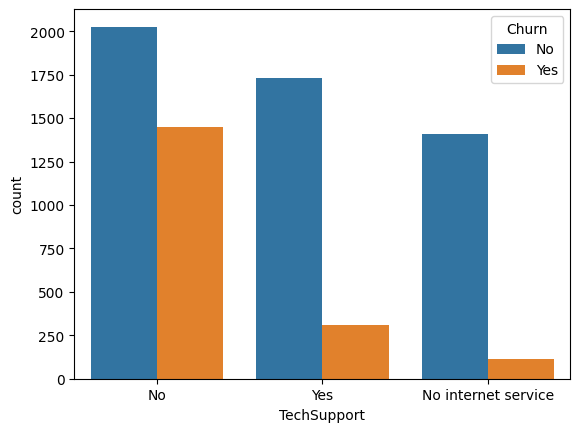

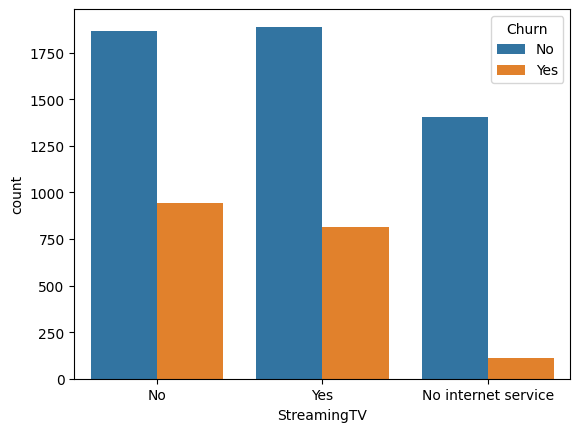

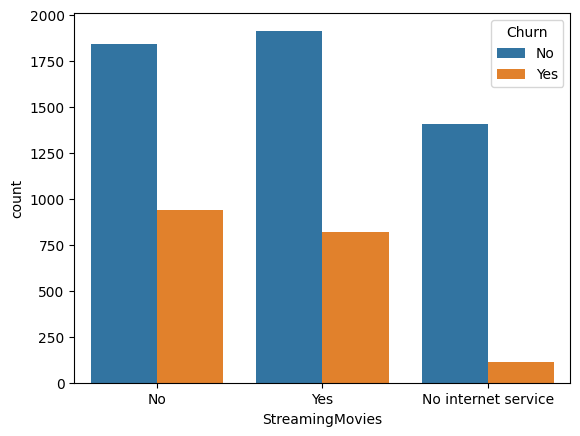

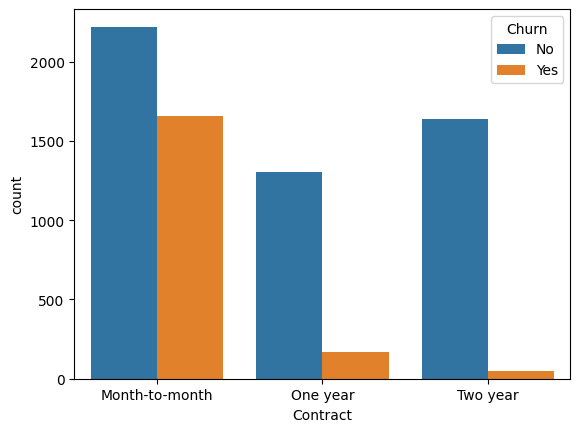

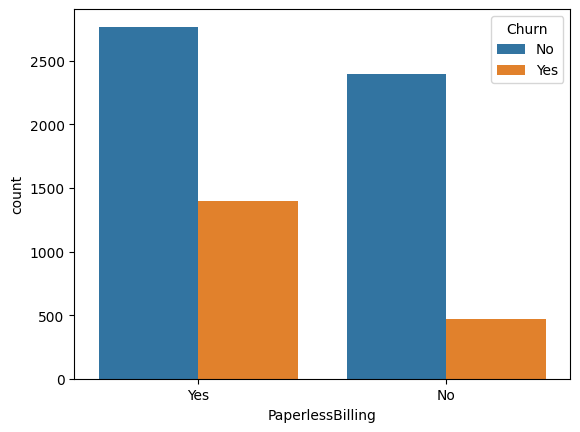

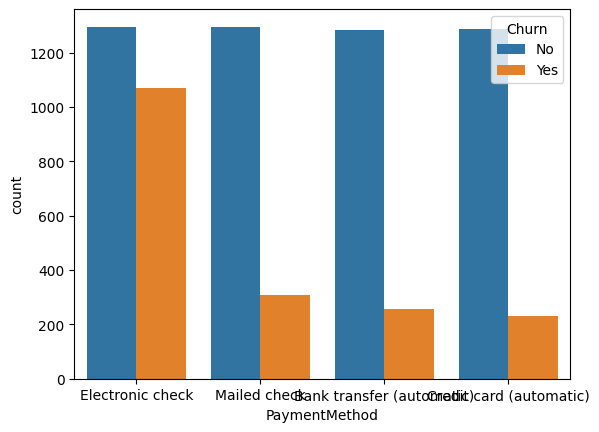

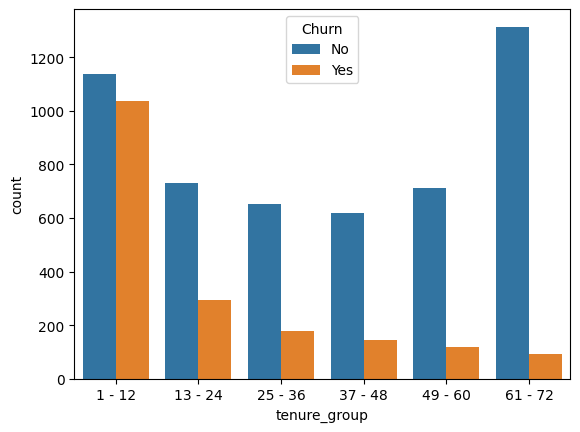

In [22]:
# Univariate Analysis
for i, predictor in enumerate(telco_data.drop(columns = ['Churn', 'TotalCharges', 'MonthlyCharges' ])):
    plt.figure(i)
    sns.countplot(data = telco_data, x = predictor, hue = 'Churn')

Text(0.5, 1.0, 'Churn by Contract Type')

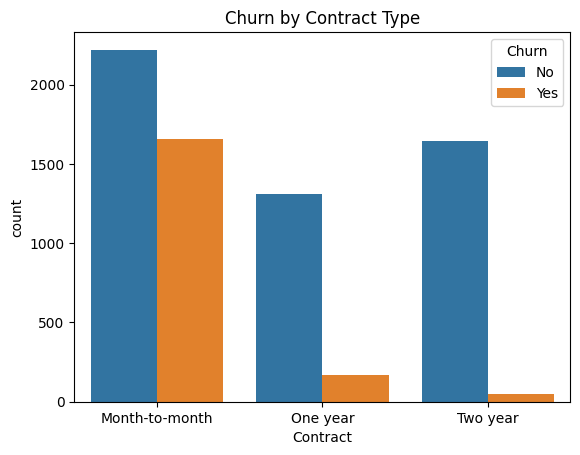

In [23]:
sns.countplot(x = 'Contract', hue = 'Churn', data = telco_base_data)
plt.title('Churn by Contract Type')

In [24]:
telco_data['Churn'] = np.where(telco_data['Churn'] == 'Yes', 1, 0)
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


**telco_data['Churn']:**
Refers to the column named "Churn" in your DataFrame telco_data. This is the column you’re about to overwrite with new values.

**np.where(condition, value_if_true, value_if_false):**
A NumPy function that checks a condition for each element. If the condition is true, it assigns one value; if false, it assigns another.

**telco_data['Churn'] == 'Yes':**
The condition being checked. For each row, it asks: “Is the value in the Churn column equal to 'Yes'?”. This produces a series of True/False values.

**In plain terms:** this code turns “Yes/No” churn data into 1s and 0s so you can analyze it mathematically.

In [25]:
telco_data_dummies = pd.get_dummies(telco_data)
telco_data_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


**pd.get_dummies(telco_data):**
This function converts categorical variables (like "gender", "InternetService", "Contract") into dummy/indicator variables.
Example: If you have a column "gender" with values "Male" and "Female", it creates two new columns:

**gender_Male (1 if Male, 0 otherwise):**
gender_Female (1 if Female, 0 otherwise). This is necessary because most machine learning models can’t handle text categories directly — they need numeric input.

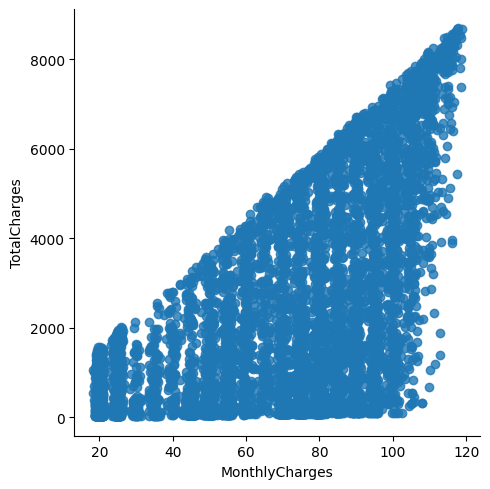

In [26]:
sns.lmplot(data = telco_data_dummies, x = 'MonthlyCharges', y = 'TotalCharges', fit_reg = False)

**sns.lmplot:** Normally draws a scatterplot with a regression line. **fit_reg=False:** Turns off the regression line, so you only see the dots.

**x='MonthlyCharges':** The horizontal axis shows each customer’s monthly charges. **y='TotalCharges':** The vertical axis shows each customer’s total charges.

**Dots (points):** Each dot represents one customer. Its position is determined by their monthly charge (x‑axis) and total charge (y‑axis).

**How to interpret the dots**
If dots rise upward as you move right, it shows that customers with higher monthly charges also tend to have higher total charges.
If dots are clustered, it means many customers share similar monthly and total charges.
If you see outliers (dots far away from the main cluster), those are unusual customers — for example, someone with very high total charges but relatively low monthly charges (likely because they’ve stayed for a long time).

👉 In plain terms: the scatter plot is a map of customers, where each dot’s location tells you how their monthly spending relates to their overall spending

A **scatter plot** works by showing how two variables relate to each other using dots on a graph. Each dot represents one observation (one row in your dataset).
**Connecting to your code:**
When you use plotting functions (like sns.scatterplot), the graph doesn’t animate dots moving — instead, it places them based on their values. The “movement” you notice is really the pattern of placement: dots aligning, clustering, or spreading out depending on how the variables interact.

Text(0.5, 0, 'MonthlyCharges')

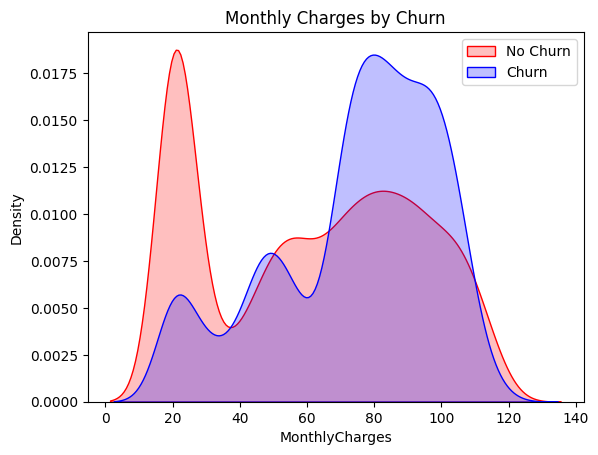

In [27]:
mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies['Churn'] == 0)], color = 'red', fill = True)
mth = sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies['Churn'] == 1)], color = 'blue', fill = True)
mth.legend(['No Churn', 'Churn'], loc = 'upper right')
mth.set_title('Monthly Charges by Churn')
mth.set_ylabel('Density')
mth.set_xlabel('MonthlyCharges')


That block of code is building a **Kernel Density Estimate (KDE) plot** to compare the distribution of monthly charges for customers who churned vs. those who didn’t:
**First line:** Plots the distribution of MonthlyCharges for customers who did not churn (Churn == 0). Red curve, filled area.

Second line: Plots the distribution of MonthlyCharges for customers who did churn (Churn == 1).

Blue curve, filled area.

legend(...): Adds labels so you can distinguish the two curves.

set_title, set_ylabel, set_xlabel: Adds descriptive titles and axis labels.

How the dots/curves “move”
Unlike a scatter plot, KDE plots don’t show individual dots. Instead, they smooth out the distribution into curves:

The height of the curve at a given MonthlyCharge shows how dense (common) that value is in the dataset.

If the red curve peaks around lower charges, it means non‑churned customers are more concentrated at those values.

If the blue curve peaks around higher charges, it means churned customers are more common at those values.

Where the curves overlap, both groups share similar charge ranges.

In plain terms
This visualization lets you compare how monthly charges differ between churned and non‑churned customers. The “movement” you see is the rise and fall of the curves, showing where each group is most concentrated.

Text(0.5, 1.0, 'Total Charges By Churn')

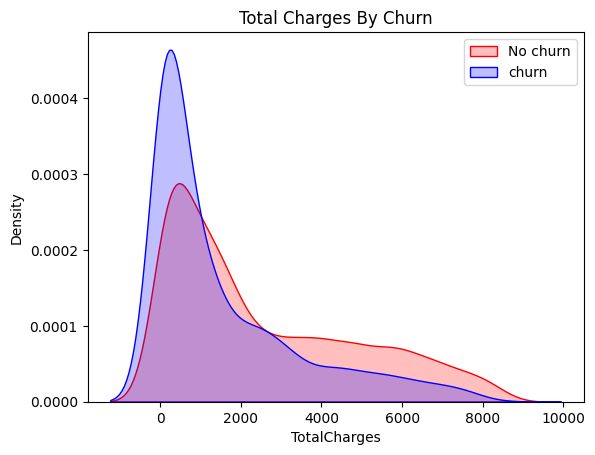

In [28]:
Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies['Churn'] == 0)], color = 'red', fill = True)
Tot = sns.kdeplot(telco_data_dummies.TotalCharges[(telco_data_dummies['Churn'] == 1)], color = 'blue', fill = True)
Tot.legend(['No churn', 'churn'], loc = 'upper right')
Tot.set_xlabel('TotalCharges')
Tot.set_ylabel('Density')
Tot.set_title('Total Charges By Churn')

<Axes: >

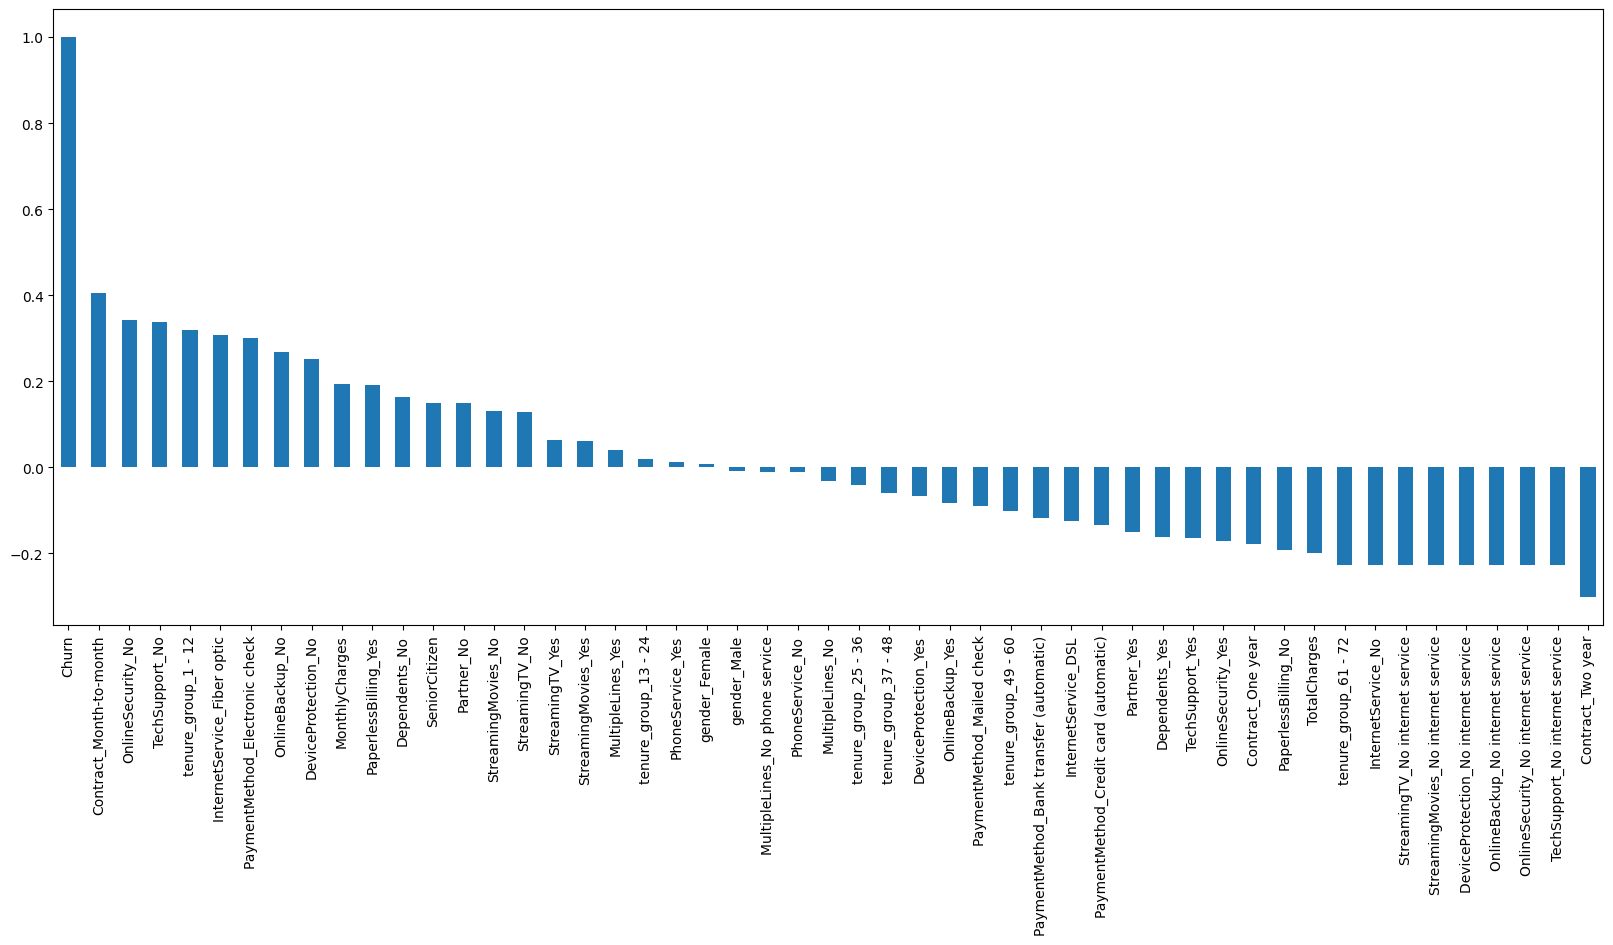

In [29]:
plt.figure(figsize = (20, 8))
telco_data_dummies.corr()['Churn'].sort_values(ascending = False).plot(kind = 'bar')

That block of code is producing a **bar chart of correlations with churn:**

**plt.figure(figsize=(20, 8)):** Sets the figure size to 20 inches wide and 8 inches tall. This makes the chart large enough to clearly display all bars.

**telco_data_dummies.corr():** Calculates the correlation matrix for all numeric columns in your dummy‑encoded dataset. Each value shows how strongly two variables move together (from −1 to +1).

**['Churn']:** Selects the column of correlations specifically with the target variable Churn. So you’re only looking at how each predictor correlates with churn.

**.sort_values(ascending=False):** Sorts the correlations from highest to lowest. This way, the strongest positive correlations with churn appear first.

**.plot(kind='bar'):** Plots the sorted correlations as a bar chart. Each bar represents one predictor variable’s correlation with churn.

**In plain terms:** This code creates a big bar chart showing which variables are most strongly linked to customer churn.

<Axes: >

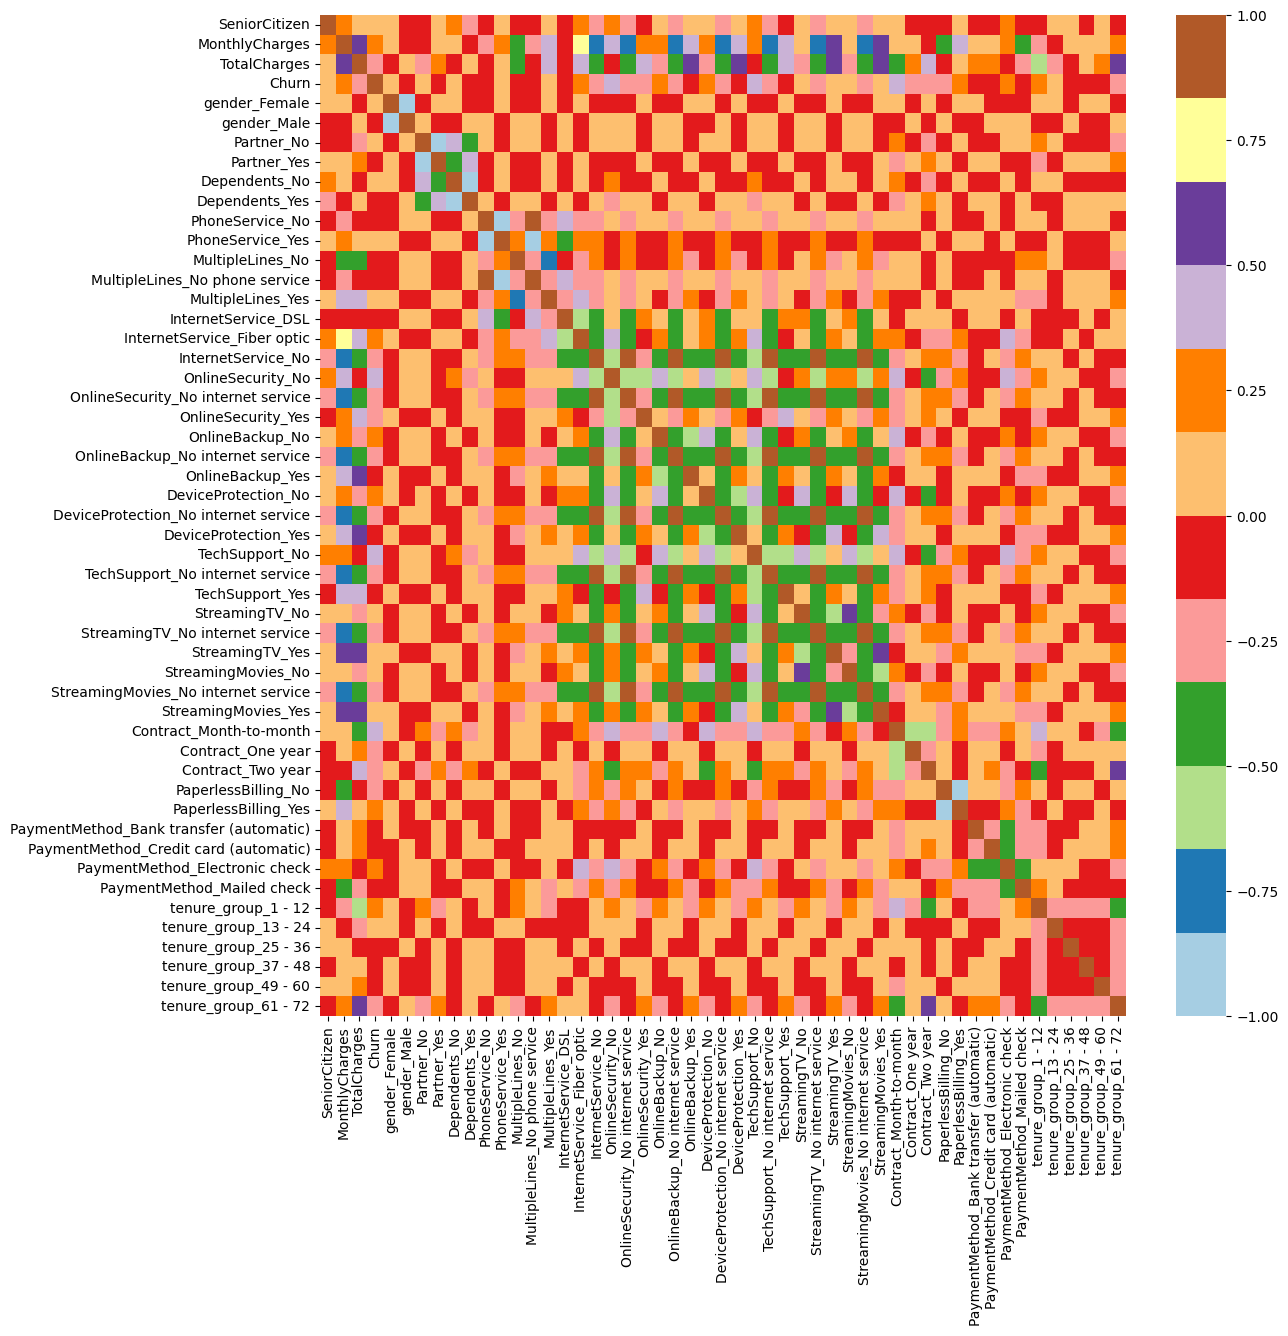

In [30]:
plt.figure(figsize = (13, 13))
sns.heatmap(telco_data_dummies.corr(), cmap = 'Paired')

That code is generating a **correlation heatmap** of your Telco dataset:

**plt.figure(figsize=(13, 13)):** Sets the figure size to 13×13 inches, making the heatmap large and readable.

**telco_data_dummies.corr():** Computes the correlation matrix for all numeric columns in your dummy‑encoded dataset. Each cell shows how strongly two variables are related (from −1 to +1).

**sns.heatmap(..., cmap='Paired'):** Plots the correlation matrix as a heatmap. Colors represent the strength and direction of correlation: Darker/lighter shades indicate stronger positive or negative relationships. Values near 0 appear neutral.

**What it shows**
The heatmap is a grid of colored squares, where each square represents the correlation between two variables. For example, the square at (MonthlyCharges, TotalCharges) will be bright if those two are strongly related.
The diagonal (variable vs. itself) will always be 1 (perfect correlation).
By scanning across the "Churn" row/column, you can quickly see which predictors are most associated with churn.

**👉 In plain terms**: this chart is a visual map of relationships in your dataset. It helps you spot which features move together and which ones are independent.

In [31]:
# Bivariate analysis
new_df1_target0 = telco_data.loc[telco_data['Churn'] == 0]
new_df1_target1 = telco_data.loc[telco_data['Churn'] == 1]

**Comment # Bivariate analysis:** This is just a note in the code. It tells you that the next steps are part of analyzing relationships between two variables (in this case, churn vs. other features).

**telco_data.loc[...]:** .loc is a pandas method used to select rows based on conditions. Inside the brackets, you specify the condition that must be true for the row to be selected.

**telco_data['Churn'] == 0:** This condition checks which rows have Churn equal to 0 (meaning the customer did not churn). The result is a boolean mask (True/False for each row).

**new_df1_target0 = telco_data.loc[telco_data['Churn'] == 0]:** Creates a new DataFrame (new_df1_target0) containing only the customers who did not churn.

**new_df1_target1 = telco_data.loc[telco_data['Churn'] == 1]:** Creates another DataFrame (new_df1_target1) containing only the customers who did churn.

**In plain terms:** This code splits your dataset into two groups:
new_df1_target0: customers who stayed (no churn).
new_df1_target1: customers who left (churn).

👉 This is useful for bivariate analysis, because you can now compare how different features (like tenure, monthly charges, contract type) differ between churned and non‑churned customers.

In [74]:
def unipot(df, col, title, hue = None):
    
    sns,set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams['axes.labelsize'] = 20
    plt,rcparams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30
    
    
    temp = pd.Series(data = hue)
    fig, ax = plt.subplots()
    width = len(df[col].unique()) + 7 + 4*len(temp.unique())
    fig.set_size_inches(width, 8)
    plt.xticks(rotation = 45)
    plt.yscale('log')
    plt.title(title)
    ax = sns.countplot(data = df, x = col, order = df[col].value_counts().index, hue = hue, palette = 'bright')
    
    plt.show()

**Function definition:**
uniplot(df, col, title, hue=None) defines a reusable plotting function.

**Parameters:**
**df:** the DataFrame you want to plot.
**col:** the column to analyze.
**title:** the chart title.
**hue:** optional grouping variable (e.g., Churn) to split bars by categories.

**Seaborn/Matplotlib styling:**

**sns.set_style('whitegrid'):** sets a clean background with grid lines.

**sns.set_context('talk'):** makes fonts and elements larger, good for presentations.

**plt.rcParams[...]:** customizes label size, title size, and spacing.

**Dynamic figure sizing:**

**temp = pd.Series(data=hue):** converts the hue into a Series to count unique categories.

**width = len(df[col].unique()) + 7 + 4*len(temp.unique()):** calculates width based on how many unique values are in the column plus adjustments for hue categories.

**fig.set_size_inches(width, 8):** sets the figure size dynamically.

**Axis formatting:**

**plt.xticks(rotation=45):** rotates x-axis labels for readability.

**plt.yscale('log'):** sets y-axis to logarithmic scale (useful if counts vary widely).

**plt.title(title):** sets the chart title.

**Plotting:**

**sns.countplot(...):** creates a bar chart showing counts of each category in col.

**order=df[col].value_counts().index:** ensures bars are ordered by frequency.

**hue=hue:** splits bars by another variable (e.g., churn vs. no churn).

palette='bright': uses bright colors.

plt.show(): displays the plot.

In plain terms
This function automates the creation of a nicely formatted count plot for any categorical column in your dataset. It adjusts the figure size based on how many categories exist, uses a log scale for the y-axis to handle large differences, and can split the bars by another variable (like churn status).

👉 Essentially, it’s a custom plotting helper that makes your univariate/bivariate analysis faster and more visually appealing.

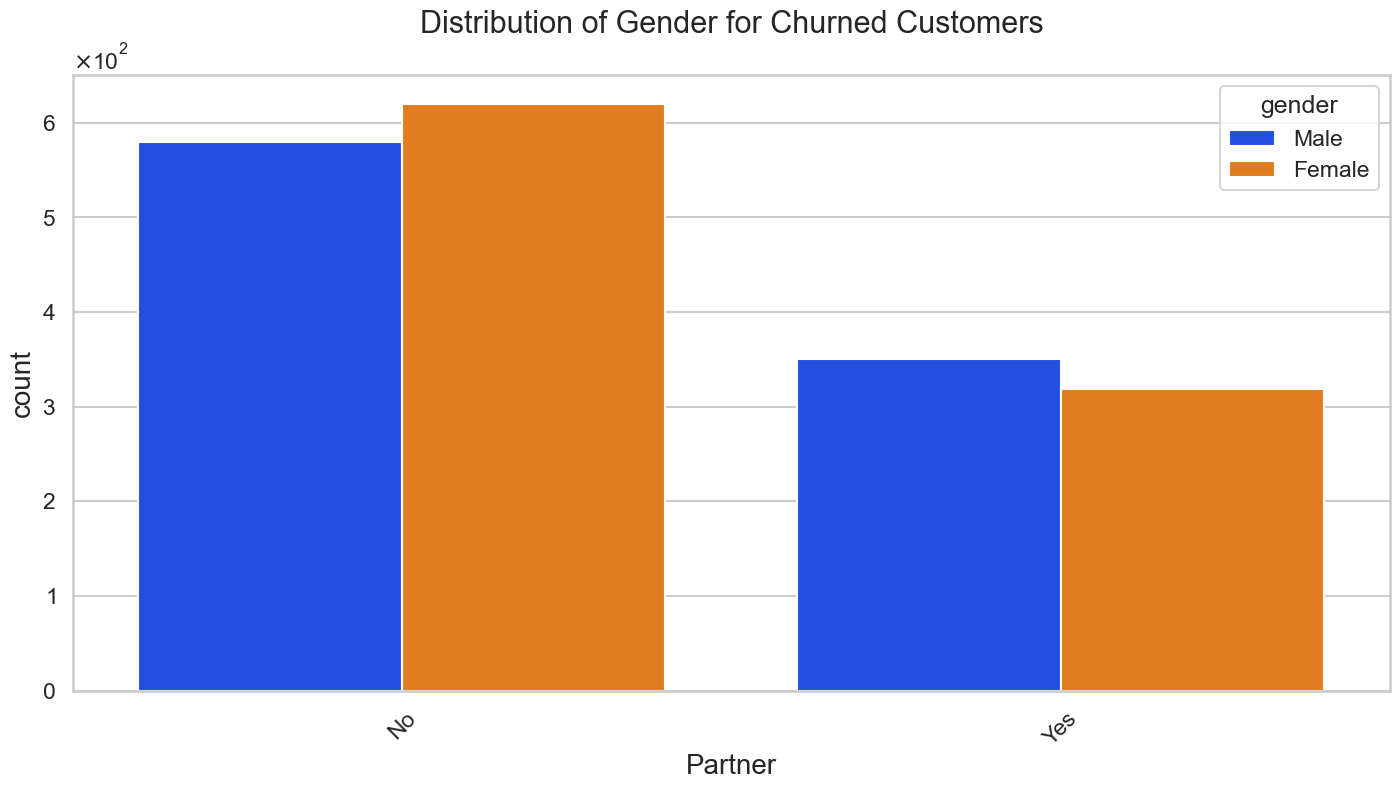

In [75]:
uniplot(new_df1_target1, col = 'Partner', title = 'Distribution of Gender for Churned Customers', hue = 'gender')

Function call: You’re using the custom uniplot function we defined earlier.

new_df1_target1: This DataFrame contains only customers who churned (Churn == 1).

col='Partner': The main categorical variable being plotted is "Partner" (whether the customer has a partner or not).

title='Distribution of Gender for Churned Customers': Sets the chart title.

hue='gender': Splits each bar by gender, so you can see how male vs. female customers are distributed within each "Partner" category.

What the plot shows
It produces a count plot (bar chart) of churned customers.

The x-axis: "Partner" categories (Yes/No).

The y-axis: number of churned customers (log scale, as defined in the function).

Each bar is divided into segments by gender (male/female), shown in different colors.

The chart title and labels make it clear you’re analyzing churned customers only.

In plain terms
This code visualizes how churned customers are distributed by partner status, while also breaking it down by gender.

You’ll see whether churned customers with partners differ from those without partners.

You’ll also see if there’s a noticeable gender difference within those groups.


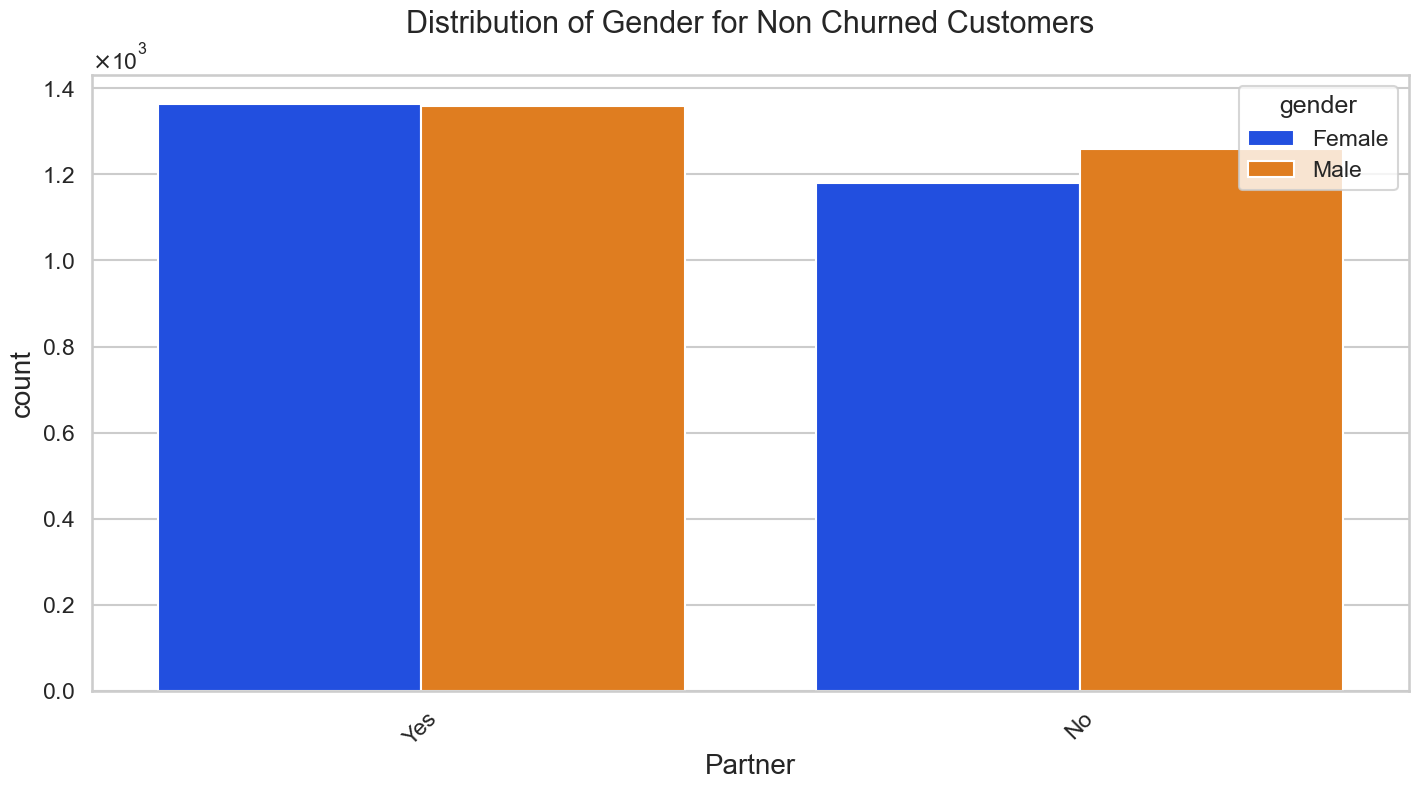

In [73]:
uniplot(new_df1_target0, col = 'Partner', title = 'Distribution of Gender for Non Churned Customers', hue = 'gender')

Function call: You’re using the custom uniplot function we defined earlier.

new_df1_target0: This DataFrame contains only customers who did not churn (Churn == 0).

col='Partner': The main categorical variable being plotted is "Partner" (whether the customer has a partner or not).

title='Distribution of Gender for Non Churned Customers': Sets the chart title.

hue='gender': Splits each bar by gender, so you can see how male vs. female customers are distributed within each "Partner" category.

What the plot shows
A count plot (bar chart) of non‑churned customers.

X-axis: "Partner" categories (Yes/No).

Y-axis: Number of non‑churned customers (log scale, as defined in the function).

Bars: Each bar is divided into segments by gender (male/female), shown in different colors.

Title: Makes it clear you’re analyzing non‑churned customers only.

In plain terms
This code visualizes how non‑churned customers are distributed by partner status, while also breaking it down by gender.

You’ll see whether customers who stayed are more likely to have partners or not.

You’ll also see if there’s a noticeable gender difference within those groups.

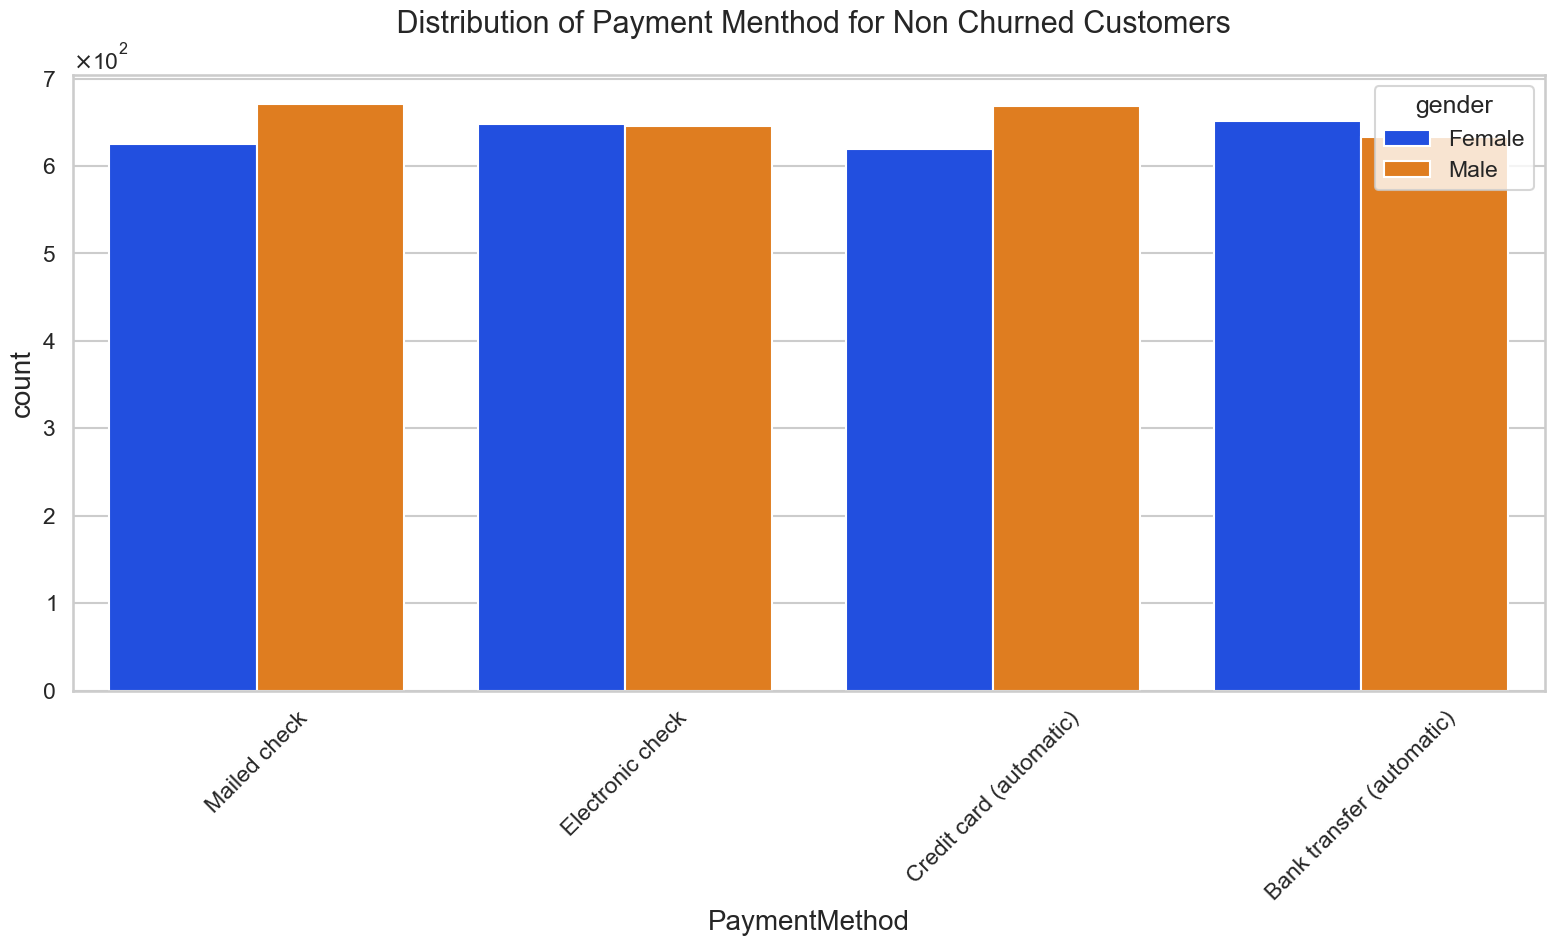

In [76]:
uniplot(new_df1_target0, col = 'PaymentMethod', title = ' Distribution of Payment Menthod for Non Churned Customers', hue = 'gender')

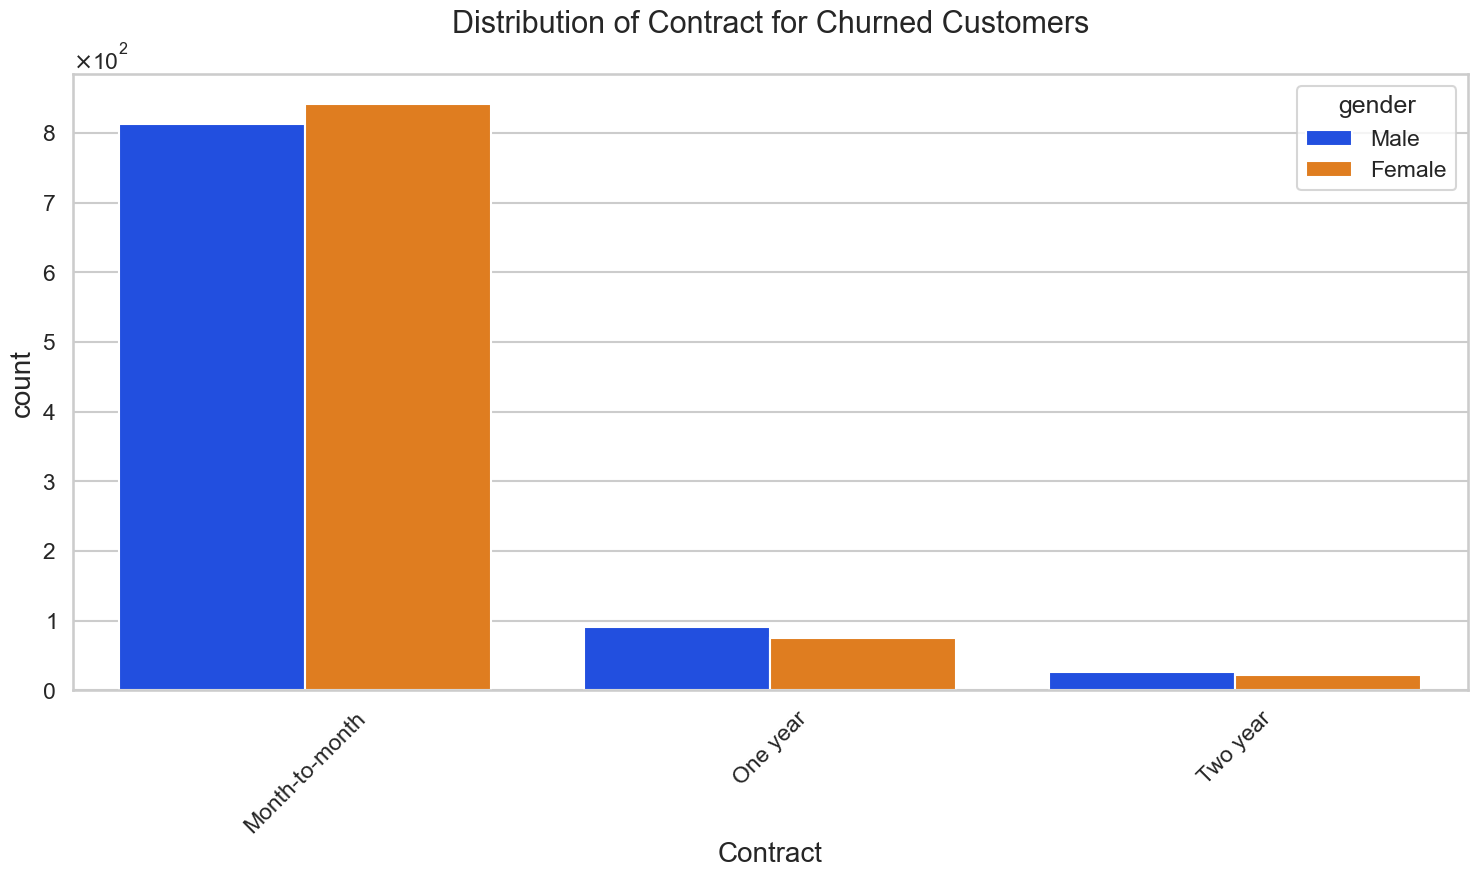

In [78]:
uniplot(new_df1_target1, col = 'Contract', title = 'Distribution of Contract for Churned Customers', hue = 'gender')

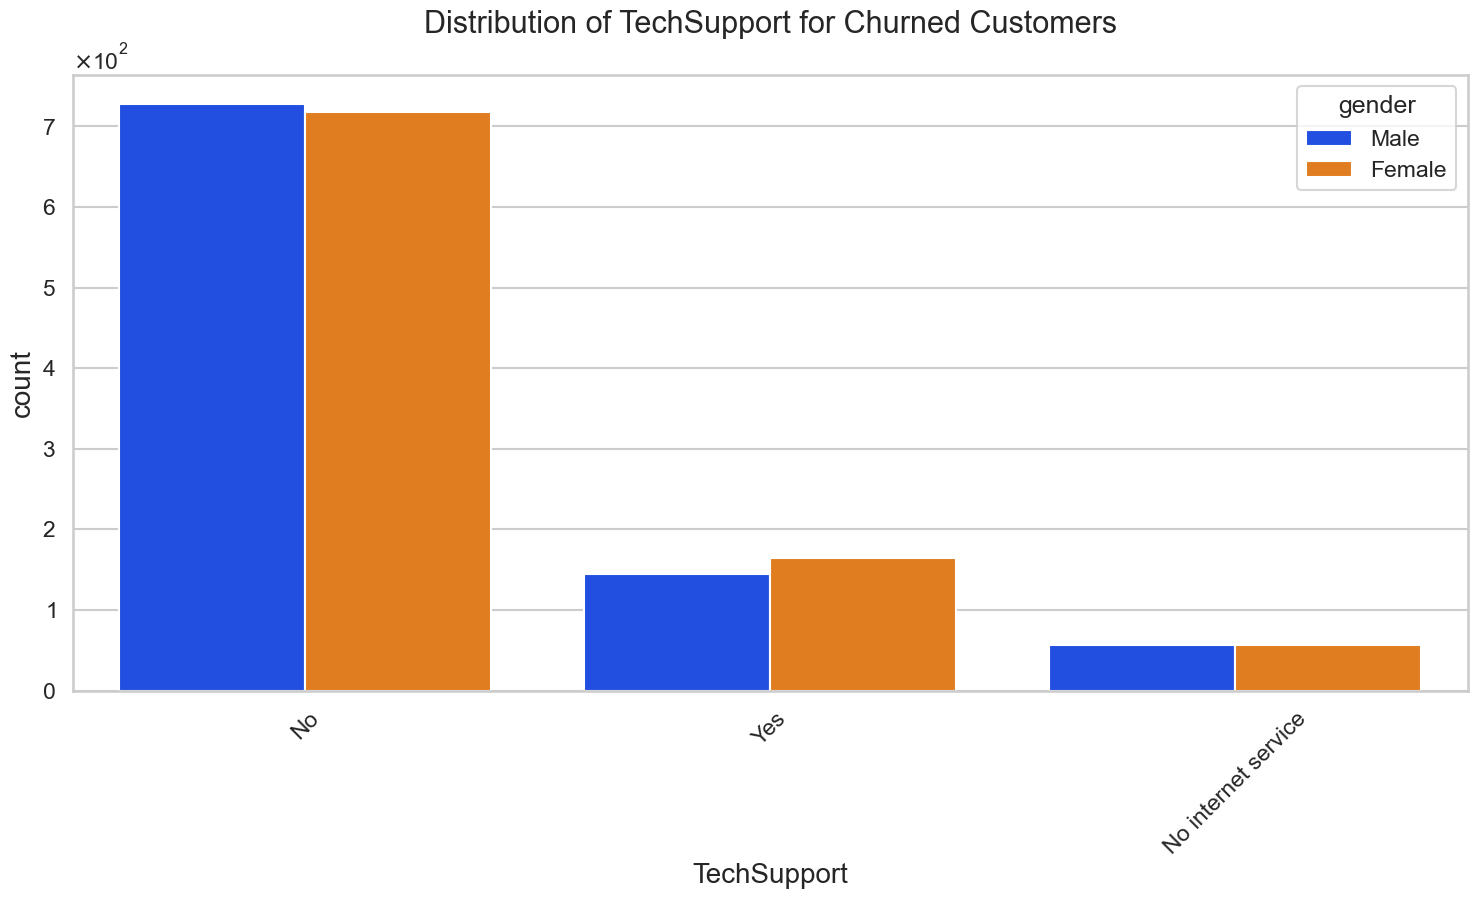

In [79]:
uniplot(new_df1_target1, col = 'TechSupport', title = 'Distribution of TechSupport for Churned Customers', hue = 'gender')

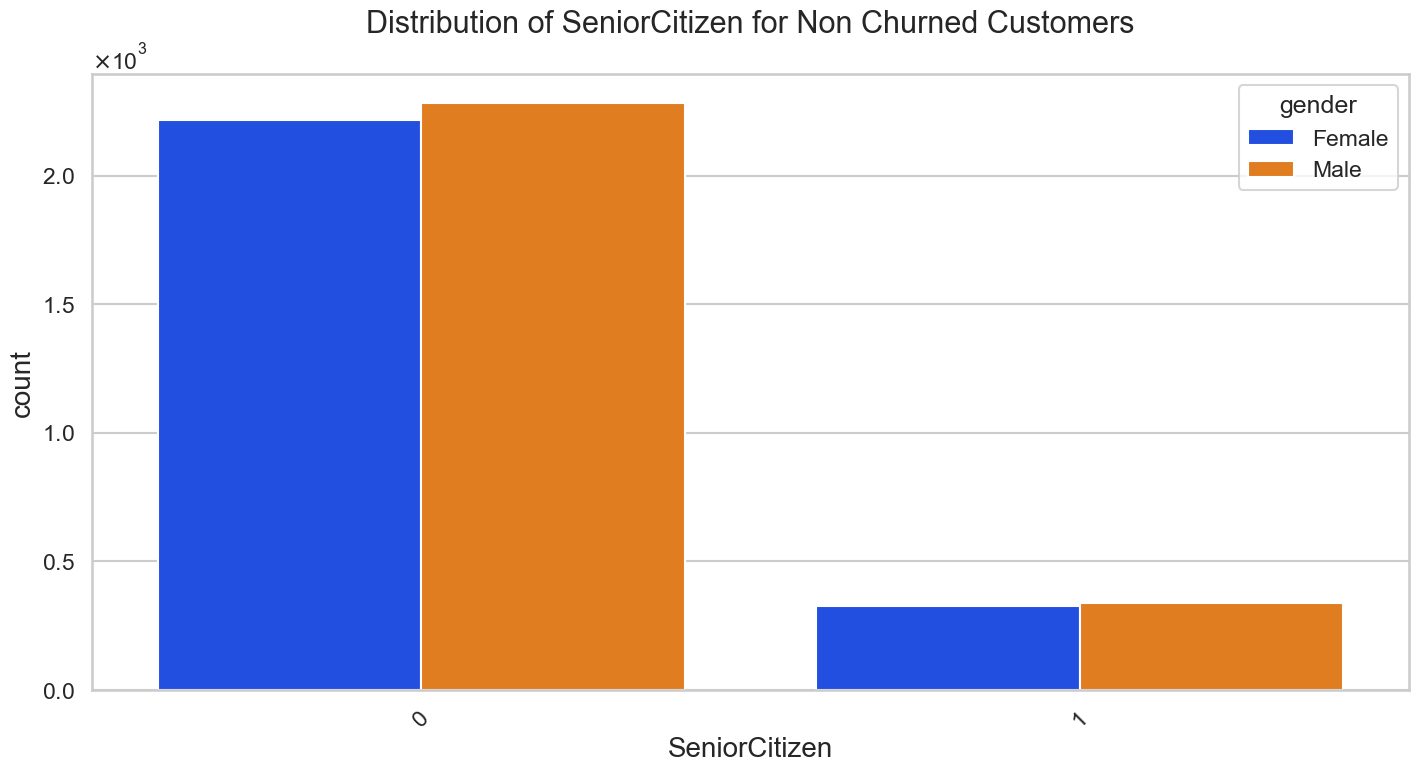

In [82]:
uniplot(new_df1_target0, col = 'SeniorCitizen', title = 'Distribution of SeniorCitizen for Non Churned Customers', hue = 'gender')